# Cleaning Workbook

This is a document that show the process of building of the cleaning function. Most of the commentary is done in the function doc strings as it seems that is the best place for someone reproducing this analysis to see the judgment calls made. Much of this commentary are my notes.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import janitor
import sklearn as skl
import random
import seaborn as sns

In [54]:
#set random seed for reproducibility
seed = 47

In [55]:
# Load the data and call it "df"
df = pd.read_csv('../data/TBI PUD 10-08-2013.csv')

In [56]:
# Clean the column names to make them easier to work with
df = df.clean_names()

In [57]:
#split the data into a training and testing set
train_df, test_df = skl.model_selection.train_test_split(df, test_size=0.2, random_state=seed)



In [58]:
# Find prop of NA for entire data set

train_df.isna().mean().mean()

np.float64(0.01210680031106887)

# Data Cleaning 


## AMS (Altered Mental State)
GCS < 15 or other signs of altered mental status (agitated, sleepy, slow to respond, repetitive questions in the ED, other)



First we clean age! Luckily there are no Na for age (need to remove any observation that has just in case)

In [59]:


def clean_age(df):
    """ 
    Cleans the age variable ('agetwoplus') by converting numeric flags to 'Yes'/'No'
    and imputes missing values based on 'ageinmonth' (24 months = 2 years).
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.

    Returns:
        pd.DataFrame: The cleaned DataFrame with imputed age values.
    """
    #  Standardize numeric codes to Yes/No strings
    df['agetwoplus'] = df['agetwoplus'].replace({1.0: 'Under 2 Years Old', 2.0: '2 Years Old or Older'})

    #  Identify rows missing 'agetwoplus'
    is_missing = df['agetwoplus'].isna()
    has_months = df['ageinmonth'].notna()

    #  Vectorized Imputation using boolean masks
    under_2_years = is_missing & has_months & (df['ageinmonth'] < 24)
    over_2_years = is_missing & has_months & (df['ageinmonth'] >= 24)

    df.loc[under_2_years, 'agetwoplus'] = 'Under 2 Years Old'
    df.loc[over_2_years, 'agetwoplus'] = '2 Years Old or Older'

    return df


In [60]:
clean_age(train_df)

print(train_df['agetwoplus'].isnull().sum())

0


In [61]:
train_df['agetwoplus'].value_counts()

agetwoplus
2 Years Old or Older    25986
Under 2 Years Old        8733
Name: count, dtype: int64

In [62]:
# Create vector of the names of AMS columns related columns
ams_columns = ['amsagitated', 'amssleep', 'amsslow', 'amsrepeat', 'amsoth']

# Change all float values of 92.0 in amc Col to NaN
for col in ams_columns:
    train_df[col] = train_df[col].replace(92.0, np.nan)

In [63]:
# Check if there are missing values in ams column
print(train_df['ams'].isnull().sum())

250


In [64]:
# Changing the value of the various AMS columns to be more interpretable. 1.0 = Yes, 0.0 = No, NaN = Missing
for col in ams_columns:
    train_df[col] = train_df[col].replace((1.0, 0.0), ('Yes', 'No'))
train_df['ams'] = train_df['ams'].replace((1.0, 0.0), ('Yes', 'No'))



In [65]:
# Check only rows where AMS is NaN.
missing_ams_df = train_df[train_df['ams'].isna()]

for i, row in missing_ams_df.iterrows():
    gcs = row['gcstotal']
    populated_ams = {
        column: row[column]
        for column in ams_columns
        if pd.notnull(row[column])
    }
    low_gcs = pd.notnull(gcs) and gcs < 15

    if low_gcs or populated_ams:
        print(f"Row {i}: alert")
        if low_gcs:
            print(f"  gcstotal: {gcs}")
        if populated_ams:
            print(f"  AMS categories with values: {populated_ams}")

This is an indication that there is no way to impute the missing AMS data points using the existing data (i.e. there was no issue where there was simply a mistake entering the data). This means that we either need to find a way to deal with NA's of which there are 250--which is not a lot. Seeing as AMS is at the top of the decision trees for in the Kuppermann paper, it seems that thisis aconsidered a clinically important measurement and therefore I hesitate to try to impute. A possibility would be to impute using a binomial model where probability is given by x/n. This feels sloppy. I think for the sake of observing domain expertise, we remove these data points. Redgarless we want to make a function that accounts foir this possibility in the test data.

Next we do some exploratory analysis.


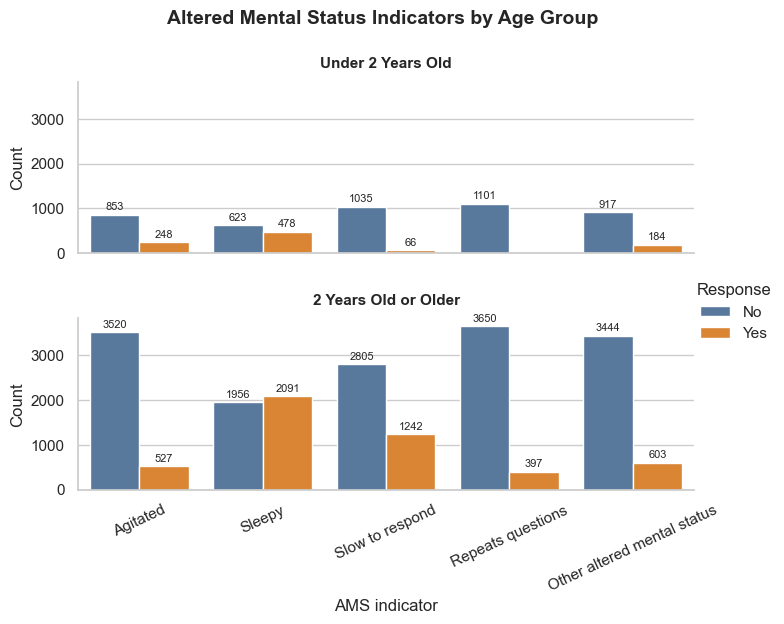

In [107]:
# Compare AMS indicators by age group using two stacked count plots.
ams_labels = {
    'amsagitated': 'Agitated',
    'amssleep': 'Sleepy',
    'amsslow': 'Slow to respond',
    'amsrepeat': 'Repeats questions',
    'amsoth': 'Other altered mental status'
}

# Reshape the AMS indicators into a long format for plotting.
df_long = (
    train_df.melt(
        id_vars=['agetwoplus'],
        value_vars=ams_columns,
        var_name='ams_metric',
        value_name='score'
    )
    .dropna(subset=['score'])
    .replace({'ams_metric': ams_labels})
)

metric_order = list(ams_labels.values())
age_order = [
    age for age in ['Under 2 Years Old', '2 Years Old or Older']
    if age in df_long['agetwoplus'].unique()
]

palette = {'No': '#4C78A8', 'Yes': '#F58518'}
g = sns.catplot(
    data=df_long,
    x='ams_metric',
    hue='score',
    row='agetwoplus',
    kind='count',
    order=metric_order,
    hue_order=['No', 'Yes'],
    row_order=age_order,
    palette=palette,
    height=3.0,
    aspect=2.4,
    sharey=True,
    legend=True
)

# Add counts above each bar and use presentation-ready labels.
for ax, age in zip(g.axes.flat, age_order):
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=2, fontsize=8)
    ax.set_title(age, fontsize=11, weight='bold', pad=10)
    ax.set_xlabel('AMS indicator')
    ax.set_ylabel('Count')
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', rotation=25)

if g._legend is not None:
    g._legend.set_title('Response')

g.fig.subplots_adjust(top=0.86, bottom=0.18, hspace=0.38)
g.fig.suptitle('Altered Mental Status Indicators by Age Group', fontsize=14, weight='bold', y=0.98)
plt.savefig('../figs/AMS_indicators_by_age_group.png', dpi=300, bbox_inches='tight')
plt.show()

Using this plot, we can make onformed cleaning decsions.

In [67]:
def clean_ams(df):
    """
    Cleans the AMS columns in the given DataFrame as well as performs various realibility checks of the data to ensure there are no inconsistencies.
    This includes ensureing all missing values are encoded as NaN, and that all values are either 1.0, 0.0, or NaN. It also checks that for all rows of ams where there is an NaN, that all of the other AMS columns should also be missing the entry for that row. 
    If there are any such rows, then I will impute the value of ams for that row based on the other AMS columns. If any of the other AMS columns are populated, then I will set ams to "Yes" for that row. If all of the other AMS columns are missing, then I will set ams to "No" for that row.
    There are no judgement calls for this variable, any imputations are logical progressions of the data and are not based on any assumptions about the patient or their condition.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing AMS columns.

        Returns: pd.DataFrame: The cleaned DataFrame.


    """
    
    ams_columns = ['amsagitated', 'amssleep', 'amsslow', 'amsrepeat', 'amsoth']
    
    # Change all float values of 92.0 in amc Col to NaN
    for col in ams_columns:
        df[col] = df[col].replace(92.0, np.nan)

    # Changing the value of the AMS subvaribales columns to be more interpretable. 1.0 = Yes, 0.0 = No, NaN = Missing
    for col in ams_columns:
        df[col] = df[col].replace((1.0, 0.0), ('Yes', 'No'))
    df['ams'] = df['ams'].replace((1.0, 0.0), ('Yes', 'No'))

    # Impute the value of ams for rows where it is NaN based on the other AMS columns and a GCStotal of less than 15. If any of the other AMS columns are populated, then I will set ams to "Yes" for that row. If all of the other AMS columns are missing, then I will set ams to "No" for that row.
    # We also ensure if there are no;s for the ams columns then ams is set to "No" for that row. This is because if there are no;s for the ams columns then it is logical to assume that the patient does not have AMS and therefore ams should be set to "No" for that row.
    # If all of the other AMS columns are missing, then I will set ams to "No" for that row.


    missing_ams_df = df.loc[df['ams'].isna()].copy()

    for i, row in missing_ams_df.iterrows():
        low_gcs = pd.notna(row['gcstotal']) and row['gcstotal'] < 15
        has_ams_indicator = row[ams_columns].eq('Yes').any()

        

    for i, row in missing_ams_df.iterrows():
        gcs = row['gcstotal']
        populated_ams = {
            column: row[column]
            for column in ams_columns
            if pd.notnull(row[column])
        }
        low_gcs = pd.notnull(gcs) and gcs < 15

        if low_gcs or populated_ams:
            if low_gcs:
                df.at[i, 'ams'] = 'Yes'
            elif populated_ams:
                df.at[i, 'ams'] = 'Yes'
            else:
                df.at[i, 'ams'] = 'No'

    return df

In [68]:
#Make sure the function is working--it seems to be working as intended, the ams column is now populated for all rows and the value counts of the ams column are consistent with the other AMS columns.

clean_ams(train_df)

values = {}

for col in ams_columns:
    values[col] = train_df[col].value_counts(dropna=False)
    print(f"{col}:\n{values[col]}\n")

# Check unique values in each AMS column separately
unique_values = {}

for col in ams_columns:
    unique_values[col] = train_df[col].unique()
    print(f"{col} unique values:\n{unique_values[col]}\n")
for col in ams_columns:
    values[col] = train_df[col].value_counts()
    print(values[col])



amsagitated:
amsagitated
NaN    29571
No      4373
Yes      775
Name: count, dtype: int64

amssleep:
amssleep
NaN    29571
No      2579
Yes     2569
Name: count, dtype: int64

amsslow:
amsslow
NaN    29571
No      3840
Yes     1308
Name: count, dtype: int64

amsrepeat:
amsrepeat
NaN    29571
No      4751
Yes      397
Name: count, dtype: int64

amsoth:
amsoth
NaN    29571
No      4361
Yes      787
Name: count, dtype: int64

amsagitated unique values:
[nan 'No' 'Yes']

amssleep unique values:
[nan 'No' 'Yes']

amsslow unique values:
[nan 'No' 'Yes']

amsrepeat unique values:
[nan 'Yes' 'No']

amsoth unique values:
[nan 'No' 'Yes']

amsagitated
No     4373
Yes     775
Name: count, dtype: int64
amssleep
No     2579
Yes    2569
Name: count, dtype: int64
amsslow
No     3840
Yes    1308
Name: count, dtype: int64
amsrepeat
No     4751
Yes     397
Name: count, dtype: int64
amsoth
No     4361
Yes     787
Name: count, dtype: int64


# Hematoma and Related Variables

Hematoma is a localized collect of blood under the skin. The variables concerning hematomas are if ther is a swelling (hematome), and if so, the location and the size.

In [69]:
def clean_hema(df):
    """
    This function cleans all variable related to Hematoma: hema, hemaloc, and hemasize. All missing values are recorded as NaN.
    For hema, all values are either Yes or No (or NaN) corresponding to 1 and 0 respectivly.
    For hemaloc, all 92 are mapped to NaN and we check to ensure there are no unexpected values not 1, 2, or 3 
    For hema size, we fix 92 to make it NaN additionally we check to ensure there are no unexpected values not 1, 2, or 3
    We then look to see if we can back inpute on the indicator hema, if there is a hema size or location, then we can set hema to Yes. If there is no hema size or location, then we can set hema to No.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing hema columns.


        Returns: pd.DataFrame: The cleaned DataFrame.
    """

    hema_columns = ['hema', 'hemaloc', 'hemasize']

    # Change all float values of 92.0 in hema variables to NaN
    for col in hema_columns:
        df[col] = df[col].replace(92.0, np.nan)

    # Rename the values of the hemavaribales for interpretability.
    df['hema'] = df['hema'].replace((1.0, 0.0), ('Yes', 'No'))
    df['hemaloc'] = df['hemaloc'].replace((1.0, 2.0,3.0),('frontal', 'occipital', 'parietal/temporal'))
    df['hemasize'] = df['hemasize'].replace((1.0, 2.0,3.0),('small', 'medium', 'large'))

    # Check for any unexpected values in the hema variables; if there is such a value then fill in NaN. 
    for col in hema_columns:
        unexpected_values = df[~df[col].isin(['Yes', 'No', 'frontal', 'occipital', 'parietal/temporal', 'small', 'medium', 'large']) & df[col].notnull()]
        if not unexpected_values.empty:
            df.at[unexpected_values.index, col] = np.nan

    # If NaN for the hema variable, then check the other two variables to see if we can back inpute the value of hema. If there is a hema size or location, then we can set hema to Yes. If there is no hema size or location, then we can set hema to No.
    hema_missing_df = df[df['hema'].isna()]
    for i, row in hema_missing_df.iterrows():
        hema_size = row['hemasize']
        hema_loc = row['hemaloc']
        if pd.notnull(hema_size) or pd.notnull(hema_loc):
            df.at[i, 'hema'] = 'Yes'
        else:
            df.at[i, 'hema'] = 'No' 

    return df


In [70]:
# Check to make sure the function worked
clean_hema(train_df)

hema_columns = ['hema', 'hemaloc', 'hemasize']

values = {}

for col in hema_columns:
    values[col] = train_df[col].value_counts(dropna=False)
    print(f"{col}:\n{values[col]}\n")

# Check unique values in each Hematoma column separately
unique_values = {}

for col in hema_columns:
    unique_values[col] = train_df[col].unique()
    print(f"{col} unique values:\n{unique_values[col]}\n")
for col in hema_columns:
    values[col] = train_df[col].value_counts()
    print(values[col])

hema:
hema
No     20992
Yes    13727
Name: count, dtype: int64

hemaloc:
hemaloc
NaN                  21151
frontal               7181
parietal/temporal     3511
occipital             2876
Name: count, dtype: int64

hemasize:
hemasize
NaN       21578
medium     7684
small      2816
large      2641
Name: count, dtype: int64

hema unique values:
['No' 'Yes']

hemaloc unique values:
[nan 'occipital' 'frontal' 'parietal/temporal']

hemasize unique values:
[nan 'medium' 'small' 'large']

hema
No     20992
Yes    13727
Name: count, dtype: int64
hemaloc
frontal              7181
parietal/temporal    3511
occipital            2876
Name: count, dtype: int64
hemasize
medium    7684
small     2816
large     2641
Name: count, dtype: int64


# Loss of consciousness 

Given by two variables, locseperate which give history of LOC and loclen whihc gives duration of LOC



In [71]:
# Exploratory of LOC variables 
loc_columns = ['locseparate', 'loclen']


values = {}

for col in loc_columns:
    values[col] = train_df[col].value_counts(dropna=False)
    print(f"{col}:\n{values[col]}\n")

# Check unique values in each Hematoma column separately
unique_values = {}


for col in loc_columns:
    unique_values[col] = train_df[col].unique()
    print(f"{col} unique values:\n{unique_values[col]}\n")
for col in loc_columns:
    values[col] = train_df[col].value_counts()
    print(values[col])

locseparate:
locseparate
0.0    27790
1.0     3819
2.0     1606
NaN     1504
Name: count, dtype: int64

loclen:
loclen
92.0    29294
NaN      2035
2.0      1463
3.0       894
1.0       748
4.0       285
Name: count, dtype: int64

locseparate unique values:
[ 0.  1.  2. nan]

loclen unique values:
[92.  2.  1. nan  3.  4.]

locseparate
0.0    27790
1.0     3819
2.0     1606
Name: count, dtype: int64
loclen
92.0    29294
2.0      1463
3.0       894
1.0       748
4.0       285
Name: count, dtype: int64


In [72]:
# Check to see the values of loclen corresponding to locseparate = 2
df.loc[df['locseparate'] == 2, 'loclen'].value_counts(dropna=False)

loclen
NaN    1020
2.0     457
1.0     382
3.0     115
4.0      38
Name: count, dtype: int64

If the LOC is suspected then by giving a time this implies that suspetced means LOC by giving duration. This will be a choices in the processing: either map all "suspected" values for locseperate to NaN or leave it as is--leaves an uncertainty that I don't understand but a praticioner might? Maybe they are not sure if ther were unconsciouss? I wonder if this is an age issue? hard to tell for young kids

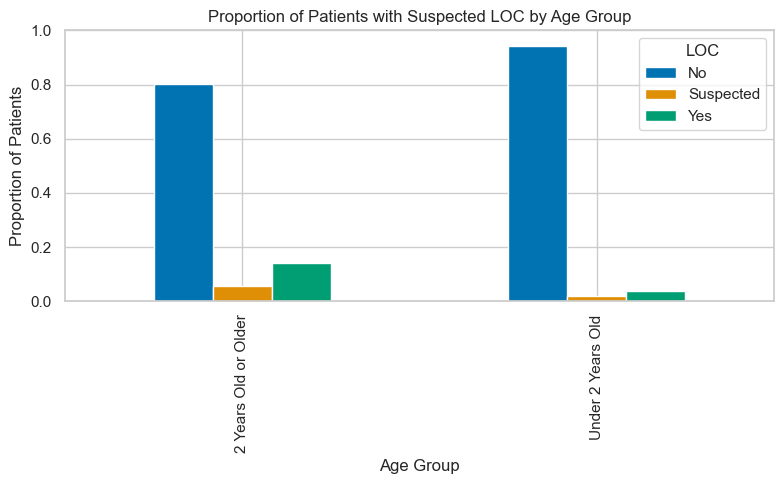

In [73]:
# Normalize LOC counts within each age group so each age group's bars sum to 1.

train_df['locseparate'] = train_df['locseparate'].replace((0.0, 1.0, 2.0),('No', 'Yes', 'Suspected'))

train_df['loclen'] = train_df['loclen'].replace((1.0, 2.0, 3.0, 4.0, 92.0),('less than 5 seconds', 'between 5 second and 1 minute', 'between 1 and 5 minutes', 'greater than 5 minutes', np.nan))

loc_proportions = pd.crosstab(
    train_df['agetwoplus'],
    train_df['locseparate'],
    normalize='index'
)

loc_proportions.plot(kind='bar', figsize=(8, 5))
plt.title('Proportion of Patients with Suspected LOC by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Patients')
plt.ylim(0, 1)
plt.legend(title='LOC')
plt.tight_layout()
plt.show()

This does not seem to be an issue, the distributions are similar.

In [74]:
def clean_loc(df, suspected_loc):
    """
    This function cleans the two LOC variables: locseparate and loclen.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing LOC columns.
        suspected_loc (Boolean): If True, then the function will treat loc length values corresponding to loc separate = "suspected" as valid inputs with clinical significance
                                If Flase, the the function will treat loc length values corresponding to loc separate = "suspected" as invalid inputs and will set them to NaN.

        Returns: pd.DataFrame: The cleaned DataFrame.
    """

    # Make locseperate and loclen more interpretable by replacing numeric codes with descriptive strings.
    df['locseparate'] = df['locseparate'].replace((0.0, 1.0, 2.0),('No', 'Yes', 'Suspected'))

    df['loclen'] = df['loclen'].replace((1.0, 2.0, 3.0, 4.0, 92.0),('less than 5 seconds', 'between 5 second and 1 minute', 'between 1 and 5 minutes', 'greater than 5 minutes', np.nan))

    # Check 

    loc_missing_df = df[df['locseparate'].isna()]
    for i, row in loc_missing_df.iterrows():
        loc_len = row['loclen']
        if pd.notnull(loc_len):
            df.at[i, 'locseparate'] = 'Yes'
        else:
              df.at[i, 'locseparate'] = 'No' 

    # If there are any "no"s for locseperate then the corresponding loclen values should be set to NaN as we give prority to the indicator
    df.loc[df['locseparate'] == 'No', 'loclen'] = np.nan


    if not suspected_loc:
        df.loc[df['locseparate'] == 'Suspected', 'loclen'] = np.nan

              

    return df

In [75]:
loc_columns = ['locseparate', 'loclen']

clean_loc(train_df, suspected_loc=True)

values = {}

for col in loc_columns:
    values[col] = train_df[col].value_counts(dropna=False)
    print(f"{col}:\n{values[col]}\n")

# Check unique values in each Hematoma column separately
unique_values = {}


for col in loc_columns:
    unique_values[col] = train_df[col].unique()
    print(f"{col} unique values:\n{unique_values[col]}\n")
for col in loc_columns:
    values[col] = train_df[col].value_counts()
    print(values[col])

locseparate:
locseparate
No           29294
Yes           3819
Suspected     1606
Name: count, dtype: int64

loclen:
loclen
NaN                              31329
between 5 second and 1 minute     1463
between 1 and 5 minutes            894
less than 5 seconds                748
greater than 5 minutes             285
Name: count, dtype: int64

locseparate unique values:
['No' 'Yes' 'Suspected']

loclen unique values:
[nan 'between 5 second and 1 minute' 'less than 5 seconds'
 'between 1 and 5 minutes' 'greater than 5 minutes']

locseparate
No           29294
Yes           3819
Suspected     1606
Name: count, dtype: int64
loclen
between 5 second and 1 minute    1463
between 1 and 5 minutes           894
less than 5 seconds               748
greater than 5 minutes            285
Name: count, dtype: int64


# Mechanism of injury

Making permuattion to back inpute to injury severity either on side of caution or not

One big issue is that we do not knwe all of the infomration we would need to decide (ie we dont know if there was an ejection in the motor collision). 
As such, for the sake of the sensitivity of the test, we are going to broaden to car acccicdents

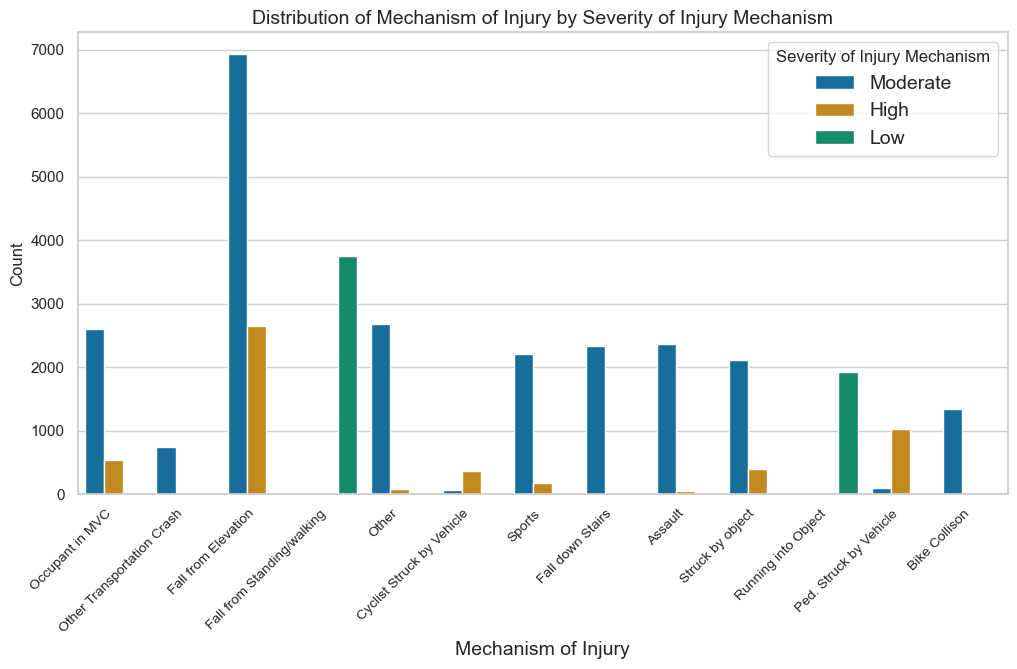

In [109]:
mech_map = {
        1.0: 'Occupant in MVC',
        2.0: 'Ped. Struck by Vehicle',
        3.0: 'Cyclist Struck by Vehicle',
        4.0: 'Bike Collison',
        5.0: 'Other Transportation Crash',
        6.0: 'Fall from Standing/walking',
        7.0: 'Running into Object',
        8.0: 'Fall from Elevation',
        9.0: 'Fall down Stairs',
        10.0: 'Sports',
        11.0: 'Assault',
        12.0: 'Struck by object',
        90.0: 'Other'
    }
    
train_df['injurymech'] = train_df['injurymech'].replace(mech_map)
train_df['high_impact_injsev'] = train_df['high_impact_injsev'].replace({1.0: 'Low', 2.0: 'Moderate', 3.0: 'High'})

# Plot of distruibution of mechanism of injury based on high impact injury severity, include labels and font is increased to 14 for readability, using color blind freidnly template from seaborn, then save plot to pdf
sns.set_theme(style="whitegrid", palette="colorblind")
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='injurymech', hue='high_impact_injsev')
plt.title('Distribution of Mechanism of Injury by Severity of Injury Mechanism', fontsize=14)
plt.xlabel('Mechanism of Injury', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Severity of Injury Mechanism', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)  
plt.savefig('../figs/injury_mechanism.png', bbox_inches='tight')

In [77]:



def clean_mechanism_injury(df, extreme_caution=False):
    """
    Cleans mechanism of injury columns and imputes missing injury severity values
    based on mechanism types alone when detailed sub-variables are unavailable.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing mechanism and severity columns.
        extreme_caution (bool): If True, remaining unmapped missing values will be 
                                imputed as 'Severe'; if False, as 'Moderate'.

    Returns:
        pd.DataFrame: The cleaned DataFrame with imputed injury severity.
    """
    #  Map numeric codes to descriptive strings
    mech_map = {
        1.0: 'Occupant in MVC',
        2.0: 'Ped. Struck by Vehicle',
        3.0: 'Cyclist Struck by Vehicle',
        4.0: 'Bike Collison',
        5.0: 'Other Transportation Crash',
        6.0: 'Fall from Standing/walking',
        7.0: 'Running into Object',
        8.0: 'Fall from Elevation',
        9.0: 'Fall down Stairs',
        10.0: 'Sports',
        11.0: 'Assault',
        12.0: 'Struck by object',
        90.0: 'Other'
    }
    
    df['injurymech'] = df['injurymech'].replace(mech_map)
    df['high_impact_injsev'] = df['high_impact_injsev'].replace({1.0: 'Low', 2.0: 'Moderate', 3.0: 'High'})

    #  Define High / Severe Severity Mechanisms
    high_mechanisms = [
        'Occupant in MVC',
        'Ped. Struck by Vehicle',
        'Cyclist Struck by Vehicle',
        'Fall from Elevation',
        'Fall down Stairs',
        'Struck by object'
    ]
    high_rule = df['injurymech'].isin(high_mechanisms)

    # Define Low Severity Mechanisms
    low_mechanisms = [
        'Fall from Standing/walking',
        'Running into Object'
    ]
    low_rule = df['injurymech'].isin(low_mechanisms)

    # Apply Imputations to Missing Severity Values
    missing_mask = df['high_impact_injsev'].isna()

    # Apply High Severity Imputations
    df.loc[missing_mask & high_rule, 'high_impact_injsev'] = 'High'
    
    # Apply Low Severity Imputations
    df.loc[missing_mask & low_rule, 'high_impact_injsev'] = 'Low'

    # Apply Fallback / Cautionary Imputations for Remaining Unmapped Cases
    still_missing = df['high_impact_injsev'].isna()
    default_severity = 'High' if extreme_caution else 'Moderate'
    df.loc[still_missing, 'high_impact_injsev'] = default_severity

    return df




In [78]:
mech_of_injury_columns = ['injurymech', 'high_impact_injsev']

clean_mechanism_injury(train_df, extreme_caution=True)

values = {}

for col in mech_of_injury_columns:
    values[col] = train_df[col].value_counts(dropna=False)
    print(f"{col}:\n{values[col]}\n")


unique_values = {}


for col in mech_of_injury_columns:
    unique_values[col] = train_df[col].unique()
    print(f"{col} unique values:\n{unique_values[col]}\n")
for col in mech_of_injury_columns:
    values[col] = train_df[col].value_counts()
    print(values[col])

injurymech:
injurymech
Fall from Elevation           9578
Fall from Standing/walking    3762
Occupant in MVC               3141
Other                         2762
Struck by object              2521
Assault                       2424
Sports                        2380
Fall down Stairs              2344
Running into Object           1931
Bike Collison                 1345
Ped. Struck by Vehicle        1125
Other Transportation Crash     743
Cyclist Struck by Vehicle      428
NaN                            235
Name: count, dtype: int64

high_impact_injsev:
high_impact_injsev
Moderate    23510
Low          5693
High         5516
Name: count, dtype: int64

injurymech unique values:
['Occupant in MVC' 'Other Transportation Crash' 'Fall from Elevation'
 'Fall from Standing/walking' 'Other' 'Cyclist Struck by Vehicle' 'Sports'
 'Fall down Stairs' 'Assault' 'Struck by object' 'Running into Object'
 'Ped. Struck by Vehicle' 'Bike Collison' nan]

high_impact_injsev unique values:
['Moderate' 'Hig

# Skull Fracture

In [79]:
skull_fracture_columns = ['sfxpalp', 'sfxpalpdepress', 'sfxbas', 'sfxbashem', 'sfxbasoto', 'sfxbasper', 'sfxbasret', 'sfxbasrhi']

train_df[skull_fracture_columns].value_counts(dropna=False)

sfxpalp  sfxpalpdepress  sfxbas  sfxbashem  sfxbasoto  sfxbasper  sfxbasret  sfxbasrhi
0.0      92.0            0.0     92         92         92         92         92           33132
2.0      92.0            0.0     92         92         92         92         92             719
0.0      92.0            NaN     92         92         92         92         92             307
                         1.0     1          0          0          0          0              118
1.0      1.0             0.0     92         92         92         92         92              77
0.0      92.0            1.0     0          0          1          0          0               70
NaN      92.0            NaN     92         92         92         92         92              45
1.0      0.0             0.0     92         92         92         92         92              44
NaN      92.0            0.0     92         92         92         92         92              42
1.0      NaN             0.0     92         92   

In [80]:
def clean_skull_fracture(df):
    """
    Cleans skull fracture related columns in the given DataFrame. First replaces numeric indicators with readable text strings.
    Then the function checks for inconsistencies between the indicator variable (sfxpalp and sfxbas) and the sub-variables (sfxpalpdepress, sfxbashem, sfxbasoto, sfxbasper, sfxbasret, sfxbasrhi). If there are any inconsistencies, then the function will impute the indicator variable based on the sub-variables. If any of the sub-variables are populated with a "Yes", then the indicator variable will be set to "Yes". If all of the sub-variables are populated with a "No", then the indicator variable will be set to "No". If all of the sub-variables are missing and indictaor is NaN, then for sfxpalp the indicator variable will be set to "Unclear".
    For sfxbas, if all of the sub-variables are missing and indictaor is NaN, then the indicator variable will be set to "No" as it is logical to assume that if there is no information about the sub-variables, then there is no skull fracture.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing skull fracture columns.
    Returns:
        pd.DataFrame: The cleaned DataFrame with skull fracture columns standardized.
    """
    skull_fracture_columns = ['sfxpalp', 'sfxpalpdepress', 'sfxbas', 'sfxbashem', 'sfxbasoto', 'sfxbasper', 'sfxbasret', 'sfxbasrhi']

    # Standardize numeric codes to Yes/No strings for all skull fracture columns
    df["sfxpalp"] = df["sfxpalp"].replace({1.0: 'Yes', 0.0: 'No', 2.0: 'Unclear'})

    df["sfxpalpdepress"] = df["sfxpalpdepress"].replace({1.0: 'Yes', 0.0: 'No', 92.0: np.nan})


    df["sfxbas"] = df["sfxbas"].replace({1.0: 'Yes', 0.0: 'No'})

    for col in ['sfxbashem', 'sfxbasoto', 'sfxbasper', 'sfxbasret', 'sfxbasrhi']:
        df[col] = df[col].replace({1.0: 'Yes', 0.0: 'No', 92.0: np.nan})

    for i, row in df.iterrows():
        # Check for inconsitencies in sfxpalp and its sub-variables
        if pd.isna(row['sfxpalp']):
            if row[['sfxpalpdepress']].eq('Yes').any():
                df.at[i, 'sfxpalp'] = 'Yes'
            else:
                df.at[i, 'sfxpalp'] = 'Unclear'
        # Make NaN no for sfxpalpdepress if sfxpalp is no or unclear since it is logical to assume that if there is no skull fracture, then there cannot be a depressed skull fracture.
        if row['sfxpalp'] in ['No', 'Unclear']:
            df.at[i, 'sfxpalpdepress'] = 'No'        

        # Check for inconsistencies in sfxbas and its sub-variables
        if pd.isna(row['sfxbas']):
            if row[['sfxbashem', 'sfxbasoto', 'sfxbasper', 'sfxbasret', 'sfxbasrhi']].eq('Yes').any():
                df.at[i, 'sfxbas'] = 'Yes'
            elif row[['sfxbashem', 'sfxbasoto', 'sfxbasper', 'sfxbasret', 'sfxbasrhi']].eq('No').all():
                df.at[i, 'sfxbas'] = 'No'
            else:
                df.at[i, 'sfxbas'] = 'No'  # Default to No if all sub-variables are missing

        # If sfxbas is No, then all sub-variables should be No as well since it is logical to assume that if there is no skull fracture, then there cannot be any of the sub-variables.
        if row['sfxbas'] == 'No':
            df.at[i, 'sfxbashem'] = 'No'
            df.at[i, 'sfxbasoto'] = 'No'
            df.at[i, 'sfxbasper'] = 'No'
            df.at[i, 'sfxbasret'] = 'No'
            df.at[i, 'sfxbasrhi'] = 'No'

        

    return df

In [81]:
clean_skull_fracture(train_df)

skull_fracture_columns = ['sfxpalp', 'sfxpalpdepress', 'sfxbas', 'sfxbashem', 'sfxbasoto', 'sfxbasper', 'sfxbasret', 'sfxbasrhi']

train_df[skull_fracture_columns].value_counts(dropna=False)

sfxpalp  sfxpalpdepress  sfxbas  sfxbashem  sfxbasoto  sfxbasper  sfxbasret  sfxbasrhi
No       No              No      No         No         No         No         No           33132
Unclear  No              No      No         No         No         No         No             719
No       No              No      NaN        NaN        NaN        NaN        NaN            307
                         Yes     Yes        No         No         No         No             118
Yes      Yes             No      No         No         No         No         No              77
No       No              Yes     No         No         Yes        No         No              70
Unclear  NaN             No      NaN        NaN        NaN        NaN        NaN             45
Yes      No              No      No         No         No         No         No              44
Unclear  NaN             No      No         No         No         No         No              42
Yes      NaN             No      No         No   

In [82]:
print(train_df[skull_fracture_columns].isnull().sum())

sfxpalp             0
sfxpalpdepress    124
sfxbas              0
sfxbashem         366
sfxbasoto         366
sfxbasper         366
sfxbasret         366
sfxbasrhi         366
dtype: int64


# Fontanelle bulging

This is something that only happens in babies (under two) except with extreme infrequrcy if a child develops abnormmaly slowly.
We are going to make sure that is not happening. This is so rare, i am not too conerned, however I will clean it just in case. Due to rarity, I am supposing any Na are no.

Text(0, 0.5, 'Proportion of Patients')

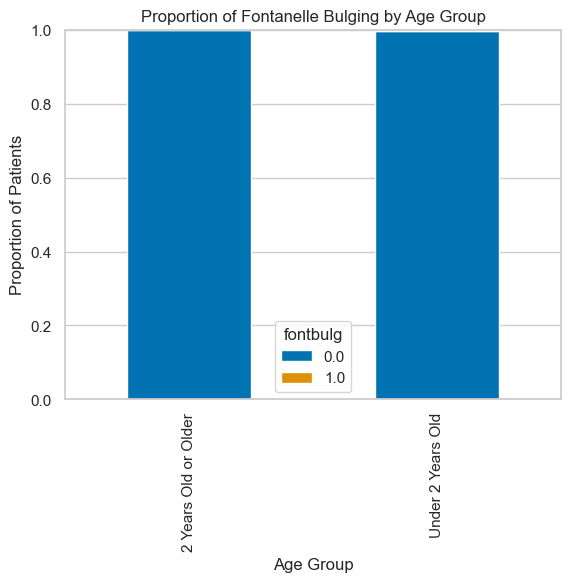

In [83]:
# Plot count of fontbulg by age group (under 2 years old vs 2 years and older) to see if there is a difference in the frequency of fontbulg between the two age groups.

train_df.groupby('agetwoplus')['fontbulg'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Proportion of Fontanelle Bulging by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Patients')    

In [84]:
train_df.groupby('agetwoplus')['fontbulg'].value_counts(normalize=True)

agetwoplus            fontbulg
2 Years Old or Older  0.0         1.000000
Under 2 Years Old     0.0         0.996628
                      1.0         0.003372
Name: proportion, dtype: float64

In [85]:
train_df.groupby('agetwoplus')['fontbulg'].value_counts(dropna=False)

agetwoplus            fontbulg
2 Years Old or Older  0.0         25986
Under 2 Years Old     0.0          8571
                      NaN           133
                      1.0            29
Name: count, dtype: int64

In [86]:
def clean_fontbulg(df):
    """
    Cleans the fontanelle bulging variable ('fontbulg') by converting numeric flags to 'Yes'/'No' and imputes missing values based on age group.
    Takes Na values and maps to No due to rarity of fontanelle bulging across all age groups.


    Parameters:
        df (pd.DataFrame): The input DataFrame.
    Returns:
        pd.DataFrame: The cleaned DataFrame with imputed fontbulg values.
    """     
    # Standardize numeric codes to Yes/No strings
    df['fontbulg'] = df['fontbulg'].replace({1.0: 'Yes', 0.0: 'No'})

    # Impute missing values 
    df.loc[df['fontbulg'].isna(), 'fontbulg'] = 'No'

    return df

In [87]:
clean_fontbulg(train_df)

train_df.groupby('agetwoplus')['fontbulg'].value_counts(dropna=False)

agetwoplus            fontbulg
2 Years Old or Older  No          25986
Under 2 Years Old     No           8704
                      Yes            29
Name: count, dtype: int64

# Glasgow Coma Score

In the paper, only those with GCS 14 or 15 were analyzed serpately from the rest. The vast amjoirty of cases are between 14 and 15. This is the problem group. I think we should also exclude this group since we are not worred about the obvious cases; the whole point is to diagnose those that are not as clear with high sensitivty. 

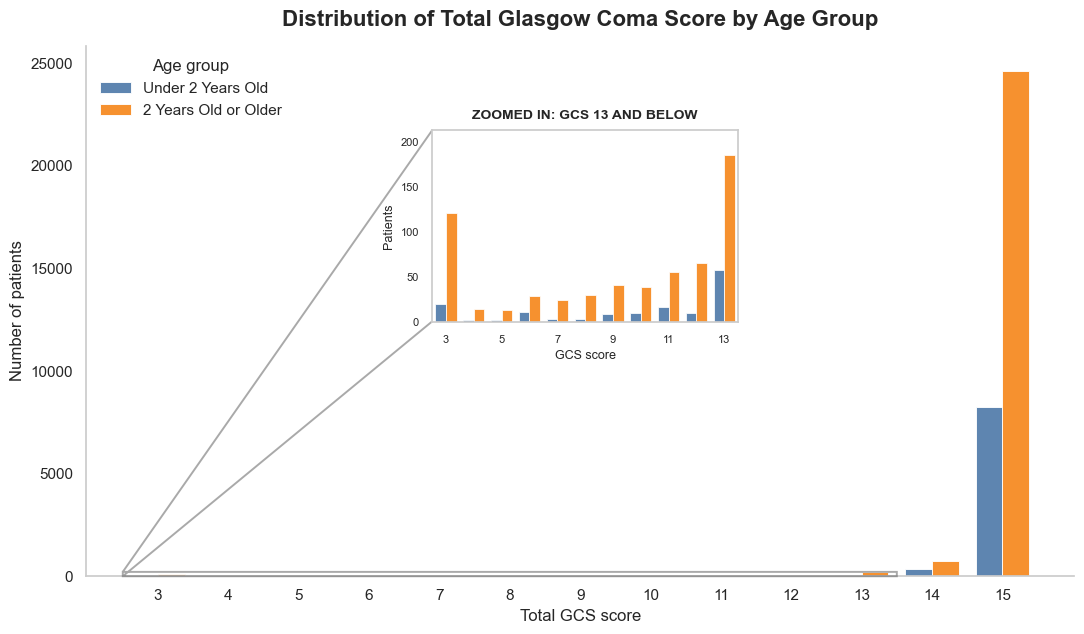

In [119]:
# Distribution of total GCS score by age group.
gcs_plot_df = train_df[['gcstotal', 'agetwoplus']].dropna().copy()
age_order = ['Under 2 Years Old', '2 Years Old or Older']
age_colors = {
    'Under 2 Years Old': '#4C78A8',
    '2 Years Old or Older': '#F58518'
}

# GCS is discrete, so count each integer score and place age groups side by side.
score_values = np.arange(
    int(gcs_plot_df['gcstotal'].min()),
    int(gcs_plot_df['gcstotal'].max()) + 1
)
score_counts = {
    age_group: (
        gcs_plot_df.loc[gcs_plot_df['agetwoplus'] == age_group, 'gcstotal']
        .value_counts()
        .reindex(score_values, fill_value=0)
        .to_numpy()
    )
    for age_group in age_order
}

fig, ax = plt.subplots(figsize=(11, 6.5))
bar_width = 0.38
bar_offsets = [-bar_width / 2, bar_width / 2]

for age_group, offset in zip(age_order, bar_offsets):
    ax.bar(
        score_values + offset,
        score_counts[age_group],
        width=bar_width,
        label=age_group,
        color=age_colors[age_group],
        alpha=0.9,
        edgecolor='white',
        linewidth=0.7
    )

ax.set_title('Distribution of Total Glasgow Coma Score by Age Group', fontsize=16, weight='bold', pad=14)
ax.set_xlabel('Total GCS score', fontsize=12)
ax.set_ylabel('Number of patients', fontsize=12)
ax.set_xticks(score_values)
ax.legend(title='Age group', frameon=False, loc='upper left')
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

# Create a centered inset that zooms into all scores of 13 and below.
inset = ax.inset_axes([0.35, 0.48, 0.31, 0.36])
for age_group, offset in zip(age_order, bar_offsets):
    inset.bar(
        score_values + offset,
        score_counts[age_group],
        width=bar_width,
        color=age_colors[age_group],
        alpha=0.9,
        edgecolor='white',
        linewidth=0.6
    )

zoom_max_score = 13
low_score_mask = score_values <= zoom_max_score
low_count_max = max(
    score_counts[age_group][low_score_mask].max()
    for age_group in age_order
)
inset.set_xlim(score_values.min() - 0.5, zoom_max_score + 0.5)
inset.set_ylim(0, low_count_max * 1.15)
inset.set_title('ZOOMED IN: GCS 13 AND BELOW', fontsize=10, weight='bold', pad=8)
inset.set_xlabel('GCS score', fontsize=9)
inset.set_ylabel('Patients', fontsize=9)
inset.set_xticks(score_values[low_score_mask][::2])
inset.tick_params(labelsize=8)
inset.grid(False)

# Mark the exact GCS <= 13 region shown in the inset.
ax.indicate_inset_zoom(inset, edgecolor='#555555', linewidth=1.4)

fig.tight_layout()
fig.savefig('../figs/gcs_total_distribution_by_age.png', dpi=300, bbox_inches='tight')
plt.show()

In [89]:
# Plot of distribution of glasgow coma score subvariables based on 

As expected! reasonable to exclude all less than 14. Now let's look by age. This seems inportant as there are two different GCS evaluations for verbal and nonverbal kids (in the paper they say at 2 years is the cutoff) so lets see if there are trends by age.

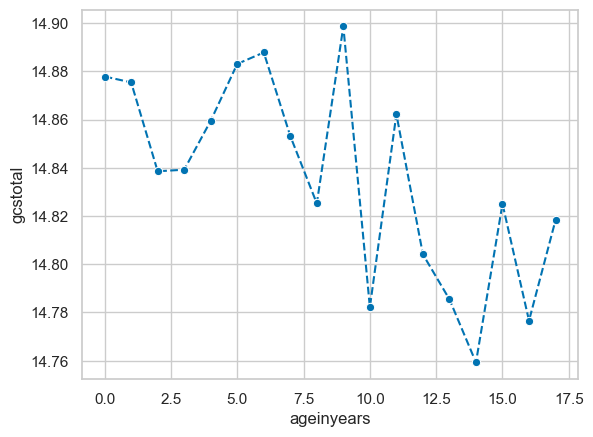

In [90]:
# Density plot of gcs total by age in years to see if there is a significant chnage point at 2 years old. We plot age in years on x axis and gcs on y
sns.lineplot(
    data=train_df, 
    x='ageinyears', 
    y='gcstotal', 
    marker='o',         
    linestyle='--',     
    errorbar=None       
)

plt.show()

In [91]:
def clean_gcs(df, include_sever_cases = False):
    """ 
    This function cleans all gcs vvariables: gcstotal, gcseye, gcsverbal, gcsmotor. We keep the numeric scores for these variables as they are clinically meaningful and we will use them in our analysis.
    It first ensure that all gcstotal are the sum of gcseye, gcserbal, and gcsmotor, if not, then we will impute the total as the sum of the three subvariables. If there are Na in the subvariables then the total will stand as is.
    If there are any missing total variables and all three of the subvariables are populated, then the total will be imputed as the sum of the three subvariables. If any of the subvariables are missing, then the total will remain missing (NaN).
    We then check to ensure gcsgroup is consistent with total score (severe = 3-13 and moderate = 14-15). If there are any inconsistencies, then we will impute the gcsgroup based on the total score. If the total score is missing, then the gcsgroup will remain missing (NaN).
    If include severe cases is True then patients with gcstotal less than 14 will be included, otherwise they will be excluded from the dataset.

    """

    gcs_columns = ['gcstotal', 'gcseye', 'gcsverbal', 'gcsmotor', 'gcsgroup']

    df['gcsgroup'] = df['gcsgroup'].replace({1.0: 'Severe', 2.0: 'Moderate'})

    # Check if gcstotal is the sum of gcseye, gcsverbal, and gcsmotor. If not, then impute the total as the sum of the three subvariables. If there are Na in the subvariables then the total will stand as is.
    df['gcstotal'] = df.apply(
        lambda row: row['gcseye'] + row['gcsverbal'] + row['gcsmotor']
        if pd.notnull(row['gcseye']) and pd.notnull(row['gcsverbal']) and pd.notnull(row['gcsmotor'])
        else row['gcstotal'],
        axis=1
    )

    # Check to ensure gcsgroup is consistent with total score (severe = 3-13 and moderate = 14-15). If there are any inconsistencies, then impute the gcsgroup based on the total score. If the total score is missing, then the gcsgroup will remain missing (NaN).
    df['gcsgroup'] = df.apply(
        lambda row: 'Severe' if row['gcstotal'] < 14 else ('Moderate' if row['gcstotal'] >= 14 else row['gcsgroup']),
        axis=1
    )

    # If all subvaribales are NA but GCS total is populated with 15, then we will impute the subvariables as 4, 5, and 6 for eye, verbal, and motor respectively. This is because a GCS total of 15 is the maximum score and indicates that the patient is fully alert and oriented, which corresponds to the maximum scores for each of the subvariables.
    df.loc[(df['gcstotal'] == 15) & (df[['gcseye', 'gcsverbal', 'gcsmotor']].isna().all(axis=1)), ['gcseye', 'gcsverbal', 'gcsmotor']] = [4, 5, 6]

    # If include severe cases is True then patients with gcstotal less than 14 will be included, otherwise they will be excluded from the dataset.
    if not include_sever_cases:
        df = df[df['gcsgroup'] == 'Moderate']   

    return df
   



In [92]:
clean_gcs(train_df, include_sever_cases=False)

gcs_columns = ['gcstotal', 'gcseye', 'gcsverbal', 'gcsmotor', 'gcsgroup']
all_missing_mask = (
    train_df['gcseye'].isna() & 
    train_df['gcsverbal'].isna() & 
    train_df['gcsmotor'].isna()
)

#  Filter the dataframe using the mask, select your columns, and sum the nulls
train_df[all_missing_mask][gcs_columns].isnull().sum()

# Check to see what the gcsgroup is for these rows. If they are all NaN, then we can assume that these patients were not assessed for GCS and we can exclude them from the dataset.
train_df[all_missing_mask]['gcstotal'].value_counts(dropna=False)



gcstotal
14.0    16
3.0     12
8.0      3
13.0     3
9.0      2
11.0     2
5.0      1
6.0      1
Name: count, dtype: int64

# Acting Normal

There are a lot NaN here, I am not sure how to handle them The altered mental state is common enough that it seems dangerous to remove.

In [93]:
train_df.groupby('agetwoplus')['actnorm'].value_counts(dropna=False)

agetwoplus            actnorm
2 Years Old or Older  1.0        19494
                      0.0         4201
                      NaN         2291
Under 2 Years Old     1.0         7139
                      0.0         1214
                      NaN          380
Name: count, dtype: int64

In [94]:
def clean_actnorm(df):
    """
    Cleans the actnorm variable by converting numeric flags to 'Yes'/'No'   

    Parameters:
        df (pd.DataFrame): The input DataFrame.
    Returns:
        pd.DataFrame: The cleaned DataFrame with actnorm values standardized.
    """
    # Standardize numeric codes to Yes/No strings
    df['actnorm'] = df['actnorm'].replace({1.0: 'Yes', 0.0: 'No'})

    return df



# Headache

There is not much that can be done to impute or fix missing values.

There is a really big discrepancy by age! Nonverbal and Na are very different

In [95]:
train_df.groupby('agetwoplus')['haseverity'].value_counts(dropna=False)

agetwoplus            haseverity
2 Years Old or Older  92.0          15759
                      2.0            4541
                      1.0            4207
                      NaN             812
                      3.0             667
Under 2 Years Old     92.0           8709
                      1.0              10
                      NaN               8
                      2.0               6
Name: count, dtype: int64

In [96]:
def clean_headache(df):
    """
    Cleans the headache related variables. Converts numeric flags to interpretible text strings.
    If headache is missing then check if severity is populated. If so then impute "Yes" to headache. 

    Parameters:
        df (pd.DataFrame): The input DataFrame.
    Returns:
        pd.DataFrame: The cleaned DataFrame with headache values standardized.
    """

    # Standardize numeric codes to Yes/No strings
    df['ha_verb'] = df['ha_verb'].replace({1.0: 'Yes', 0.0: 'No', 91.0 : "Non-verbal"})

    df['haseverity'] = df['haseverity'].replace({1.0: 'Mild', 2.0: 'Moderate', 3.0: 'Severe', 92.0 : np.nan})

    df['hastart'] = df['hastart'].replace({1.0: 'Before Injury', 2.0: 'Within 1 Hour', 3.0: '1-4 Hours After', 4.0: 'More than 4 Hours After', 92.0 : np.nan})

    # If headache is missing, check if severity is populated. If so, impute "Yes" to headache.
    df.loc[df['ha_verb'].isnull() & df['haseverity'].notnull(), 'ha_verb'] = 'Yes'

    

    return df

In [97]:
clean_headache(train_df)
train_df.groupby('agetwoplus')['haseverity'].value_counts(dropna=False)

agetwoplus            haseverity
2 Years Old or Older  NaN           16571
                      Moderate       4541
                      Mild           4207
                      Severe          667
Under 2 Years Old     NaN            8717
                      Mild             10
                      Moderate          6
Name: count, dtype: int64

<Axes: xlabel='agetwoplus'>

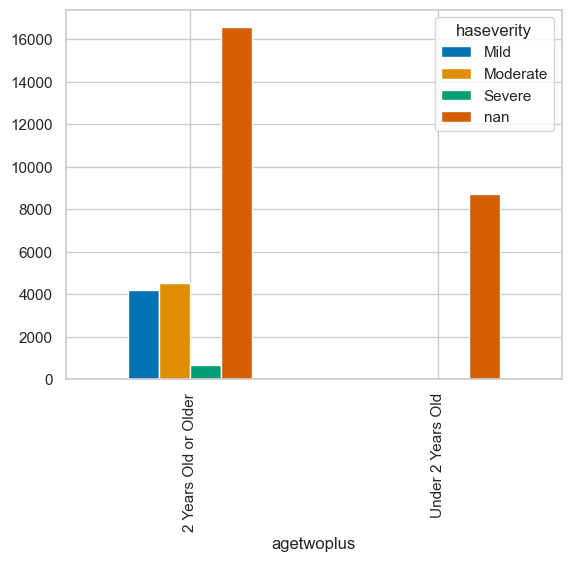

In [98]:
# Plot of headache severity by age group (under 2 years old vs 2 years and older) to see if there is a difference in the frequency of headache severity between the two age groups.
train_df.groupby('agetwoplus')['haseverity'].value_counts(dropna=False).unstack().plot(kind='bar')  


<Axes: xlabel='agetwoplus'>

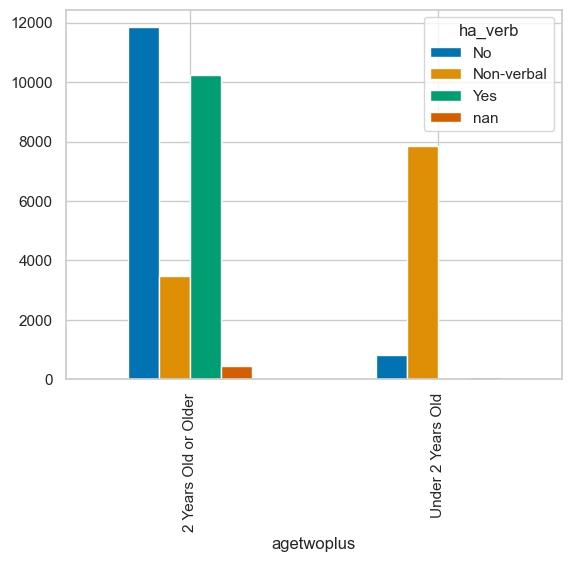

In [99]:
train_df.groupby('agetwoplus')['ha_verb'].value_counts(dropna=False).unstack().plot(kind='bar')  

# History of Vomiting

Ther are a bunch of vomit related variables. The decison rule just uses the indicator, so I will clean with an effor to try to fill in any of the indicator Na.
  

In [100]:
vomit_columns = ['vomit', 'vomitnbr', 'vomitstart', 'vomitlast']

train_df['vomit'].value_counts(dropna=False)

vomit
0.0    29724
1.0     4639
NaN      356
Name: count, dtype: int64

In [101]:
def clean_vomit(df):
    """
    Cleans vomit related variables. First convert all numeric flags to interpretible text strings. 
    Then, for NaN values in 'vomit', check if any of the other vomit-related variables are populated. If so, impute "Yes" to 'vomit'. If all other vomit-related variables are NaN, then impute "No" to 'vomit'.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
    Returns:
        pd.DataFrame: The cleaned DataFrame with vomit values standardized. 
    """
    # Convert numeric flags to text strings
    df['vomit'] = df['vomit'].replace({1.0: 'Yes', 0.0: 'No'})

    df['vomitnbr'] = df['vomitnbr'].replace({1.0: 'Once', 2.0: 'Twice', 3.0: 'Three or more', 92.0: np.nan})

    df['vomitstart'] = df['vomitstart'].replace({1.0: 'Before Injury', 2.0: 'Within 1 Hour', 3.0: '1-4 Hours After', 4.0: 'More than 4 Hours After', 92.0: np.nan})

    df['vomitlast'] = df['vomitlast'].replace({1.0: 'Less than 1 Hour', 2.0: '1-4 Hours', 3.0: 'More than 4 Hours', 92.0: np.nan})

    # For NaN values in 'vomit', check if any of the other vomit-related variables are populated. If so, impute "Yes" to 'vomit'. If all other vomit-related variables are NaN, then impute "No" to 'vomit'.
    vomit_related_columns = ['vomitnbr', 'vomitstart', 'vomitlast']
    df.loc[df['vomit'].isnull(), 'vomit'] = df[vomit_related_columns].apply(lambda x: 'Yes' if x.notnull().any() else 'No', axis=1)

    return df



# Dizzy

Since there are so many missing and is not considered as significant in paper, probably makes sense to exclude this one.

In [102]:
train_df['dizzy'].value_counts(dropna=False)

dizzy
0.0    19804
NaN    12812
1.0     2103
Name: count, dtype: int64

In [103]:
def clean_dizzy(df):
    """
    Clean the dizzy variable, convert flags to text strings
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
        
        Returns:
        pd.DataFrame: The cleaned DataFrame.
    """

    df['dizzy'] = df['dizzy'].replace({1.0: 'Yes', 0.0: 'No'})

    return df



In [104]:
clean_dizzy(train_df)

train_df['dizzy'].value_counts(dropna=False)


dizzy
No     19804
NaN    12812
Yes     2103
Name: count, dtype: int64